# 2. Spectral Hashing and OMS

## Goals:

By the end of this notebook, you should be able to understand:

1. [The challenges of Open Modification Search (OMS)](#21-open-modification-search-is-really-slow)

2. [That clustering can help speed up OMS](#22-clustering)

3. [That we need to vectorize spectra to do clustering](#why-vectorize-spectra)

4. [How to vectorize spectra](#24-peaks--vectors)

5. [Spectra that are too high-dimensional take up too much space and time to cluster](#25-ann-solo-approach)

6. How spectral hashing can reduce the dimensionality of spectra

7. How spectral hashing can help speed up OMS

in this order specifically. You can treat these goals as a table of contents for the notebook.

## Background

In order to efficiently go through the content in this notebook, we'll define a few terms and their contexts within the tutorial.

- *Sparse and Dense Vectors*:

  - A *dense vector* is a vector where most of the elements are non-zero. For example, `[1, 2, 3, 4]` is a dense vector because all elements are non-zero.

  - A *sparse vector* is a vector where most of the elements are zero. For example, `[0, 0, 3, 0, 0, 0, 7]` is a sparse vector because most elements are zero.

- *Query Spectra and Library Spectra*:

  - *Query spectra* are the spectra you obtained from your sample. You want to identify these spectra.

  - *Library spectra* are the annotated spectra in the database. You use these to identify your query spectra. If a spectrum in your sample matches a spectrum in the database, you can assign the identity of the database spectrum to your sample spectrum!

- *Post Translational Modifications (PTMs)* are chemical "add-ons" to proteins after being synthesized. They allow a given protein to diversify and be useful far past the dictates of its transcription and synthesis, especially given that they are reversible. 

  - *PTMs* are also studied for their uses in cell signalling and dynamic regulation of protein function.
  
  - For a less abstract, numerical example of what PTMs are - an oxygen atom as a PTM on a peptide is called oxidation. Oxidation shifts the mass of the peptide by a certain $\text{m/z}$. So if a peak is at $\text{m/z} = 230$ with charge $z$, adding an oxygen atom (~16 Da) will shift it to approximately $230 + 16/z$.

- *Database Search* is a way to check if a peptide from your sample already exists within a database.

  - That is, if you have a spectrum but don't know its identity, checking the relevant databases (eg. humans for human samples, e. coli for e. coli samples) allows you to use someone else's identification ("annotation", rather) of that spectrum.

    - This is done via a variety of algorithms (depends on the tool you're using) to determine how close of a match a spectrum is to the database's annotated spectrum.
    
    - Note that in traditional proteomics, we can safely consider only peptides from the database with the same mass as our fragmented spectra.

In [4]:
# @title Run this cell to import all necessary packages

%pip install matplotlib

import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pyteomics
from pyteomics import mzml, auxiliary
import plotly.io as pio
import plotly.tools as tls
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rapidhash import rapidhash
from IPython.display import display, Latex
from util import *
from matplotlib.lines import Line2D

import importlib
import SpectrumWithTransformations as swt_module
import SpectrumWithTransformations
from spectrum_utils.proforma import Modification

importlib.reload(swt_module)

Note: you may need to restart the kernel to use updated packages.


<module 'SpectrumWithTransformations' from '/home/avni/source/repos/MS_spectra_encoding/SpectrumWithTransformations.py'>

## 2.1 Open Modification Search is really slow

Let's put those last two concepts together and see what happens.

Suppose we've just received a sample of proteins for e. coli and it's our job to figure out what they are. Let's further imagine that a considerable amount of these proteins are *post translationally modified*, maybe even multiple times! We throw them in the mass spectrometer, fragment them, and get a set of MS2 spectra. We want to identify these spectra, call them "query spectra".

Now, our usual approach would be to run a database search against an e. coli protein database. However, because of the PTMs, many of the peptides in our sample will have different masses than those in the database. We need to account for those mass shifts, what we call **Open Modification Search (OMS).**

In OMS, every peptide in the database is considered as a potential match to every MS2 fragmentation spectrum. When a peptide-spectrum match is found, you can look for *mass shifts* to identify PTMs. All possible modifications are implicitly considered. You can imagine that this is very useful for discovering unexpected or novel modifications, but it comes at a cost - it is *very* computationally expensive because we literally compare every spectrum to every peptide in the database.


## 2.2 Clustering


Instead of comparing every spectrum to every annotated peptide, we can use **clustering** to group similar spectra together. Namely, we can cluster all of our *library spectra* together based on their similarity, and then for each *query spectrum* we want to identify, we only need to compare it to one representative spectrum from each cluster.

To reiterate - if we know the identity of one spectra in a group ahead of time then we have a good idea of the identity of every spectrum in that cluster. This allows us to make just a single (or a few) comparisons per cluster instead of to every peptide in every cluster.

This approach was used by [ANN-SoLo](https://pubs.acs.org/doi/full/10.1021/acs.jproteome.9b00291), which we'll follow and try to motivate throughout this notebook

<center><img src="ANN-SoLo-Graphical-Abstract.jpeg" width="685" height="400"></center>

#### Clustering == Lego Sorting

To understand clustering better, imagine you're building a large Lego set with ~2,000 pieces.

*The naive approach:*
* Dump all pieces out at once
* For each instruction, search through the entire pile to find the piece you need

*The clustering approach:*
* Dump all pieces out at once
* First, sort pieces into piles by shape (2x4 studs, 1x2 studs, etc.)
* For each instruction, go directly to the relevant pile

If you grab any piece from a pile, it's representative of all pieces in that pile. This lets you quickly skip irrelevant piles. Now imagine 2,000,000 pieces — the efficiency gain becomes enormous.

> There's a balance between "too specific" (too many small piles) and "too generic" (piles with mixed pieces). The same applies to clustering spectra.

---

For spectra, clustering works the same way:

| Lego | Spectra |
|:---:|:---:|
| Group similar pieces into piles | Group similar spectra into clusters |
| Identify one piece per pile | Identify one spectrum per cluster (using traditional search) |
| All pieces in pile share that identity | All spectra in cluster share that peptide identity |


#### A natural question arises: *How do we actually cluster spectra?*

The graphics below walk through clustering spectra in 2 dimensions. In reality, we'll work with hundreds of dimensions, but the core idea is exactly the same.

<img src="Clustering-1.jpeg" width="500" height="675">
<img src="Clustering-2.jpeg" width="500" height="675">


#### Why Vectorize Spectra

I hope that you came away with the idea that similarity == distance. When two spectra map to nearby points, they're similar. When they're far apart, they're different. If similarity == distance though, then how do we measure distance between spectra in the first place?

In order to measure distance between spectra (and transitively to cluster), we need to represent each spectrum as a single point in space. 

## 2.4 Peaks => Vectors

When you look at a spectrum, you see 2 dimensions: m/z on the x-axis and intensity on the y-axis; but imagine each possible m/z value as its own "dimension." 

We create a vector mapping m/z bins to intensities with 1 Da bins:

* Bin 100: m/z 100-101 (intensity = 0)
* Bin 101: m/z 101-102 (intensity = 500)
* Bin 102: m/z 102-103 (intensity = 0)
* Bin 103: m/z 103-104 (intensity = 1200)
* ... and so on

Each bin conforms to a single index, so this gives us a vector like `[...,0, 500, 0, 1200, ...]` representing the spectrum.

Let's make this a bit more concrete. 

In [12]:
# @title Throughout our examples, we'll use one sample mzml file. Run this to define the path.
 
full_calibrated_mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

Failed to convert matplotlib figure to Plotly; falling back to matplotlib display


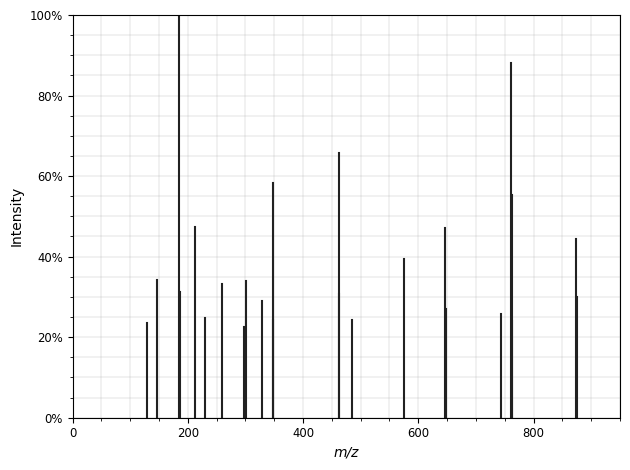

In [13]:
# @title The get_MS2_object function takes in a path and a scan number. This scan number tells it to retrieve the MS2 corresponding to the scan number from that mzML file.

ms2_spectrum_5672 = get_MS2_object(mzml_path=full_calibrated_mzml_path, scan=5672)

plot_MS2(ms2_spectrum=ms2_spectrum_5672)

Grab the intensity and mz arrays from the object above:

In [8]:
# grab mz values from that ms2 object as a list
spectrum_mz = ms2_spectrum_5672.mz
# grab intensity from that ms2 object as a list
spectrum_int = ms2_spectrum_5672.intensity

# Pretty display of m/z and intensity as a table
df = pd.DataFrame({'spectrum_mz': spectrum_mz, 'spectrum_int': spectrum_int})
display(df.style.format({'spectrum_mz': '{:.2f}', 'spectrum_int': '{:.2f}'}))

,spectrum_mz,spectrum_int
0,129.10,2174.82
1,147.11,3145.84
2,185.16,9230.92
3,186.17,2883.78
4,213.16,4380.56
5,229.12,2282.99
6,260.20,3063.12
7,298.14,2072.46
8,300.16,3142.87
9,328.19,2672.69


As you can see, the max m/z is 875.49. Let's use an even 880 for simplicity. We're also going to continue to use the 0th and 1st indices of the intensity and mz arrays for this notebook.

Recall that our goal is to be able to determine the distance between two spectra by representing each spectrum as a point in space.

In order to do so, we had divided the m/z values into bins of 1 Da each. This implies that we need 880 dimensions to represent each spectrum as a vector.

In the case that we use bins of 1 Da (rounding to nearest integer):
* Bin 129: m/z 129-130 (intensity = 2174.818)
* Bin 147: m/z 147-148 (intensity = 3145.84)
* Bin 185: m/z 185-186 (intensity = 9230.925)
* ... and so on 

Let's visualize this a bit more and see what a sample of the actual vector (or rather, list) we're talking about looks like.

---

#### Accurate vs. Naive approach

$$
\text{Approach 1: Rounding to nearest integer (1 Da bins)} \\[0.5em]
\begin{align}
\text{Here's a list with 880 zeroes filled in: } &\quad [\underset{0}{0}, \underset{1}{0}, \underset{2}{0}, \ldots, \underset{879}{0}, \underset{880}{0}] \\[0.5em]
\text{Now, let's add a sample of such values at each index:} & \quad [\underset{0}{0}, \ldots, \underset{129}{2174.818}, \ldots, \underset{147}{3145.84}, \ldots, \underset{880}{0}] 
\end{align}
$$

*We will show that this takes a lot of accuracy away, and results in quite a few collisions.*
$$
\text{Approach 2: Rounding to nearest 0.01 Da} \\[0.5em]
\begin{align}

\text{Here's a list with 88,000 zeroes filled in: } &\quad [\underset{0}{0}, \underset{1}{0}, \underset{2}{0}, \ldots, \underset{87999}{0}, \underset{88000}{0}] \\[0.5em]
\text{Now, let's add a sample of such values at each index:} & \quad [\underset{0}{0}, \ldots, \underset{12910}{2174.818}, \ldots, \underset{14711}{3145.84}, \ldots, \underset{88000}{0}] 
\end{align}
$$

=== Pairwise Spectrum Collision Analysis ===
File: Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML
Spectra analyzed: 100
Total pairs compared: 4,950

--- Bin Size = 1.0 Da ---
  Mean collision rate per pair: 13.95%
  Median collision rate: 10.53%
  Max collision rate: 100.00%
  Pairs with >50% collision: 145 (2.9%)

--- Bin Size = 0.01 Da ---
  Mean collision rate per pair: 5.19%
  Median collision rate: 0.00%
  Max collision rate: 100.00%
  Pairs with >50% collision: 52 (1.1%)

--- Improvement ---
  Reduction in mean collision rate: 62.8%


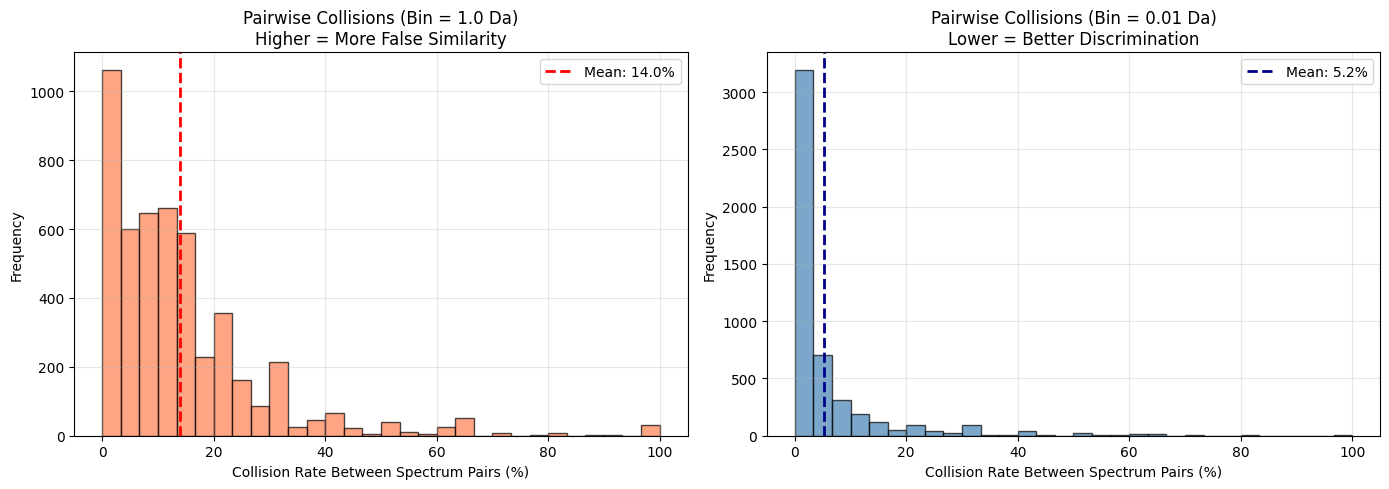

In [14]:
# @title Run this to see the difference in collisions between widths
plot_and_show_statistics_for_collisions("Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML", max_spectra=100)

#### Why collision rate between any spectrum pairs? Why not collision within a spectrum?

Our goal is eventually to cluster our spectra, regardless of what the bin size is, right? We will soon see that with coarse bins, many spectra that should be in different clusters end up in the same cluster because they appear identical.

Consider two spectra, A and B, each with only one peak:
- Spectrum A has a peak at 90.41 m/z
- Spectrum B has a peak at 90.42 m/z

| Bin Width | Spectrum A | Spectrum B | Result |
|:-----------:|:------------:|:------------:|:--------:|
| 1.0 Da | bin 90 | bin 90 | Collision! Both spectra appear identical |
| 0.01 Da | bin 9041 | bin 9042 | No collision. Spectra are correctly distinguished |

To reiterate: with coarse bins, spectra that are actually different can appear similar. This is clearly a false positive; fine bins preserve the distinction between spectra.

#### Why do we want at most 1 peak per bin anyway?

When each bin contains at most one peak, we preserve **maximum information**. If multiple peaks fall into the same bin, one intensity overwrites another in some way (either we sum intensities or we take the most recent) and we lose data. 

Finer-grained buckets reduce collisions:

1 Da => 880 buckets

0.1 Da => 8,800 buckets

0.01 Da => 88,000 buckets

This demonstrates why we need a smaller bin size. However, we can't just make bins arbitrarily small, we must choose a size that is both fine enough to preserve information and realistic for mass spectrometer accuracy.

Note that mass spectrometers have physical precision limitations too. While a spectrometer might output a value like $ m/z =  10.023130 $, it cannot actually distinguish measurements to that level of precision. In practice, mass spectrometers are reliably accurate to approximately two decimal places (0.01 Da).

In [10]:
WIDTH_OF_BIN = 0.01
LENGTH = int(max(spectrum_mz) // WIDTH_OF_BIN +1) # integer rounding up one.
print(f"We have to fit our m/zs into bins by rounding them to the nearest {WIDTH_OF_BIN}")
print(f"The length of our (simulated) array will be {LENGTH}")

We have to fit our m/zs into bins by rounding them to the nearest 0.01
The length of our (simulated) array will be 87550


## 2.5 Ann-SoLo Approach

Now that we have chosen 0.01 Da bins, we can represent that particular spectrum which we plotted and analyzed earlier as a list with length 88,000. We can also call these "dimensions," and note that we've put just one spectrum in an 88,000-dimensional space. 

You might guess that this is a massive problem for clustering and computational efficiency, and is the main motivation behind the ANN-SoLo approach.

What if, instead of using 88,000 dimensions, we had a *magical function* that could compress our spectra into a lower-dimensional space while preserving their relative distances? 

This would make it so clusters of spectra that WOULD have clustered in this ultra-high-dimensional space, also cluster in the lower dimansional space. This is where **feature hashing** comes in. This would allow us to cluster spectra much more efficiently, especially given the fact that this is all in the context of *Open Modification Search*, so our search space is that much larger. We will see this in action later, but I wanted to motivate this idea first.


<figure style="text-align:center">
  <img src="https://pubs.acs.org/cms/10.1021/acs.jproteome.9b00291/asset/images/medium/pr9b00291_0001.gif" width="685" />
  <figcaption style="font-size:1.0em;">ANN-SoLo Plan.</figcaption>
</figure>

We'll be implementing the code for the two steps shown above:

**Spectrum Binning**: Convert spectrum to sparse vector using fine m/z bins (we've already seen numerical examples of this!)

**Feature Hashing**: Compress sparse vector to much smaller, fixed-size vector


### Step 1: Spectrum Binning

**Goal**: Convert spectrum to sparse vector using fine m/z bins

We've already chosen our bin width (0.01 Da). Now we'll define a function to convert m/z values to their binned index.

For example: 129.103 m/z → index 12910

In [16]:
# @title Conversion to sparse vector

def to_idx(mz):
    """
    Convert m/z value to a sparse vector index.
    """
    # concretely: 129.103 // 0.01 == 12910
    return int(mz // WIDTH_OF_BIN) # rounds down to nearest 0.01.

#### Sparse Vector Optimization

We're going to make another optimization before we continue with the feature hashing approach. With 88,000 possible bins but only 24 peaks in this spectrum, most bins are empty. Storing ~88,000 zeros is wasteful right now as well, so instead we'll use a dictionary mapping `{mz_bin: intensity}`.

This **dictionary** stores only the non-zero entries:

Instead of:
```
[0, 0, 0, ..., 2174.818, 0, 0, ..., 3145.84, 0, 0, ..., 0]  # 88,000 elements!
```

We store:
```
{12910: 2174.818, 14711: 3145.84, ...}  # Only 24 entries
```

In [22]:
# @title Create the sparse representation: map from m/z indices to intensities

mz_intensity_map = {}
# Populate the sparse vector with our spectrum data
for i, mz in enumerate(spectrum_mz):
    # Convert each m/z to its corresponding index
    mz_index = to_idx(mz)
    # Store the intensity
    mz_intensity_map[mz_index] = spectrum_int[i]

What does this look like?

In [23]:
# @title Run to visualize the dictionary 

from IPython.display import display
rows = []
for bin_idx, intensity in sorted(mz_intensity_map.items()):
    orig_mz = next((mz for mz in spectrum_mz if to_idx(mz) == bin_idx), None)
    rows.append({'m/z bin': bin_idx, 'Intensity': intensity, 'Original m/z': orig_mz})
df_mz = pd.DataFrame(rows)
display(df_mz.style.format({'Intensity': '{:.3f}', 'Original m/z': '{:.4f}'}))

print(f"Total entries: {len(mz_intensity_map)} (instead of ~88,000 zeros!)")

,m/z bin,Intensity,Original m/z
0,12910,2174.818,129.1023
1,14711,3145.840,147.1128
2,18516,9230.925,185.1649
3,18616,2883.776,186.1681
4,21315,4380.564,213.1598
5,22911,2282.987,229.1184
6,26019,3063.123,260.1971
7,29814,2072.459,298.1401
8,30015,3142.870,300.1557
9,32818,2672.693,328.1873


Total entries: 24 (instead of ~88,000 zeros!)


#### Step 1 Complete! 

 We have a sparse, binned, vector representation of our spectrum.

 ---
 

#### Step 2: Feature Hashing

Now for the second step of the pipeline:

**Goal:** Compress the sparse vector (with indices up to 88,000) into a fixed-size vector of 800 dimensions.

#### Why do we need this?

Our dense dictionary is memory efficient, but we still have a problem. **It's only dense in name, not functionality.**


Clustering algorithms need fixed-size vectors. You can't easily compute distances between dictionaries with different keys. As such, the potential dimensionality is still huge. Even with only 24 entries, those indices span 0-88,000 and will need to be translated back into vectors for clustering.

Here, I will once again remind you of our *magic function* from earlier. [Click this to review that cell again](#25-ann-solo-approach)

#### Hash Function

A *hash function* has 3 main properties.

1. **Fixed output size**: Given any input, its output is of the same size every time.

In [ ]:
hashed_string = hash("this is a string")

hashed_another_string = hash("this is another string")

print(hashed_string)
print(hashed_another_string)

assert(len(str(hashed_string)) == len(str(hashed_another_string)))
print("Both hashes have the same length")

-4032823956171221255
-2030433692255640910


2. **Deterministic**: Same input -> same output every time

In [ ]:
hashed_string = hash("this is the same string")
same_hashed_string = hash("this is the same string")

print(hashed_string)
print(same_hashed_string)

assert(hashed_string == same_hashed_string)
print("Both hashes are identical")

2747009960681780928
2747009960681780928


3. **Fast**: Efficiently computable

In [ ]:
import timeit


def hash_varied_strings():
    for _ in range(100000):
        hash(f"this is string number {np.random.randint(0, 1000000)}")


hash_time_varied = timeit.timeit(hash_varied_strings, number=1)


print(f"Time taken to hash 100,000 varied strings: {hash_time_varied} seconds")

Time taken to hash 100,000 varied strings: 0.36278587500055437 seconds


#### Our Magic Function == Hash Function

We wanted to map down from our sparse vector to a much lower dimensional one.

<details>
<summary><strong>Why 800 buckets?</strong></summary>

It's somewhat arbitrary, but we aim to balance two concerns:
- **Large enough** to minimize collisions (different peaks hashing to the same bucket)
- **Small enough** to be computationally efficient for clustering

800 is a good middle ground for typical spectrum.

</details>

A hash function maps any sparse index to a fixed range of buckets. Here we use 800:

$$\text{hash}(12910) \rightarrow 347 \quad \text{(bucket between 0 and 799)}$$

$$\text{hash}(14711) \rightarrow 102 \quad \text{(another bucket)}$$

Similar spectra (which we'd like to identify for clustering purposes) will have similar hash vectors because they share many of the same m/z bins, *which will hash to the same buckets* because of the deterministic nature of hash functions.

In [36]:
HASH_BUCKETS = 800

#### The hash function

We'll use `rapidhash`, a fast hash function, combined with the modulo operator to map any sparse index to a bucket in the range `[0, 799]`.

In [37]:
def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.
    
    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 799)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')
    
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % HASH_BUCKETS

In [ ]:
# @title Example: see how large indices get mapped to small buckets
print(f"Sparse index 12910 → bucket {hasher(12910)}")
print(f"Sparse index 14711 → bucket {hasher(14711)}")
print(f"Sparse index 87550 → bucket {hasher(87550)}")

Sparse index 12910 → bucket 629
Sparse index 14711 → bucket 319
Sparse index 87550 → bucket 354


#### Handling collisions

What happens when two different m/z bins hash to the same bucket? This is called a **collision**. 

We handle collisions by **adding the intensities together**. As we will see in a minute, this is acceptable because it, on average, happens rarely enough that it preserves similarity between vectors, which is the key idea behind clustering + hashing.

In [ ]:
# @title Populate our final hash vector with intensities, handling collisions by summation

# Initialize our final hash vector with all zeros
hash_vector = [0] * HASH_BUCKETS 

# Populate the hash buckets with intensities from our sparse map
for sparse_idx, intensity in mz_intensity_map.items():
    # Map the sparse index to a bucket
    bucket_idx = hasher(sparse_idx)
    
    # Add intensity to that bucket (handles collisions by summation)
    hash_vector[bucket_idx] += intensity

#### The final hash vector

In [ ]:
# @title Display the hash vector
non_zero_buckets = [(i, val) for i, val in enumerate(hash_vector) if val > 0]

print(f"Hash vector has {len(non_zero_buckets)} non-zero buckets out of {HASH_BUCKETS} total\n")

nonzero_hash_df = pd.DataFrame(non_zero_buckets, columns=['Bucket', 'Intensity'])
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(nonzero_hash_df)

Hash vector has 24 non-zero buckets out of 800 total



,Bucket,Intensity
0,40,3142.87
1,78,2072.46
2,115,5098.79
3,236,2240.40
4,241,4356.98
5,246,2672.69
6,251,2494.96
7,255,4098.93
8,270,3063.12
9,319,3145.84


#### Step 2 complete!

We now have a fixed-size hash vector.

---

## 2.6 Summary: The Complete Pipeline

We've completed the full spectral hashing pipeline:

| Step | Representation | Size |
|------|----------------|------|
| **Original** | (m/z, intensity) pairs | 24 peaks |
| **Step 1: Binning** | Sparse dictionary | 24 entries (of 88,000 possible) |
| **Step 2: Hashing** | Fixed-size vector | 800 dimensions |

---

### Putting It All Together: The OMS Workflow

Now we can see how spectral hashing enables efficient OMS. Define an embedding function:

```python
def embed_spectrum(mz_array, intensity_array) -> list[float]:
    # Step 1: Bin → Step 2: Hash
    return hash_vector  # length 800
```

---

**Phase 1: Build the Library (one-time preprocessing)**

1. For all spectra with **known identity** (from a spectral library), imagine we have such a function:
```python
hash_vector_library = embed_spectrum(library_spectrum.mz: list[int], library_spectrum.intensity:list[int])
```

2. Cluster all library hash vectors using cosine similarity.

> **Lego analogy:** Sort all your known Lego pieces into piles before you start building.

---

**Phase 2: Identify Unknown Spectra (query phase)**

3. For each unknown **query spectrum**:
```python
hash_vector_query = embed_spectrum(query_spectrum.mz, query_spectrum.intensity)
```

4. Find the nearest cluster representative using cosine similarity.

5. If similarity exceeds a threshold → assign the query the peptide identity of that cluster.

> **Lego analogy:** When you need a piece, check which pile it belongs to. All pieces in that pile share ~ the same identity.

---

**Why does this work for modified peptides?**

A modified peptide shares MOST of its fragment ions with the unmodified version. The modification only shifts a subset of peaks. Because of this shared structure, the hash vectors remain similar enough that modified and unmodified versions cluster together — enabling identification regardless of PTMs.

> **Note:** We can only compare vectors of the same length. That's why Step 2 (hashing to a fixed 800 dimensions) is essential.


---

## 2.7 Similarity Preservation: Does Hashing Actually Work?

We've claimed that hashing "preserves similarity" — that similar spectra remain similar after compression. Let's prove it.

**What does "preserve similarity" mean?**

If two spectra are similar in the original 88,000-dimensional space, they should also be similar in the compressed 800-dimensional space. The relative ordering of "similar" vs. "dissimilar" pairs should remain roughly the same.

---

#### Measuring similarity with cosine similarity

We use the **dot product** to measure how similar two vectors are:

$$\vec{x} \cdot \vec{z} > \vec{x} \cdot \vec{y} \implies \vec{x} \text{ is more similar to } \vec{z} \text{ than to } \vec{y}$$

**Cosine similarity** is just a normalized dot product (scaled between -1 and 1, like...cosine!).

**Example:**

$\vec{x} = [0, 500, 0, 1200] \quad \text{(Spectrum A)}$

$\vec{z} = [0, 480, 0, 1190] \quad \text{(Spectrum B — similar)}$

$\vec{y} = [100, 30, 2000, 0] \quad \text{(Spectrum C — different)}$

**Dot products:**

$\vec{x} \cdot \vec{z} = (0)(0) + (500)(480) + (0)(0) + (1200)(1190) = 1,668,000$

$\vec{x} \cdot \vec{y} = (0)(100) + (500)(30) + (0)(2000) + (1200)(0) = 15,000$

Since $1,668,000 \gg 15,000$, spectra A and B would be **clustered together**.

<details>
<summary>Click to see the full cosine similarity formula</summary>

$$\cos(\theta) = \frac{\vec{x} \cdot \vec{z}}{|\vec{x}| |\vec{z}|}$$

where $\theta$ is the angle between vectors. When $\theta = 0°$ (identical direction), $\cos(\theta) = 1$. When $\theta = 90°$ (perpendicular), $\cos(\theta) = 0$.
</details>

Click play to go through a visual example (no sound), starting from the top.

<video controls>
  <source src="SimilarityPreservationComplete.mp4" type="video/mp4">
</video>


> **Note:** Some similarity loss is expected due to hash collisions, but this loss is typically small and acceptable for clustering purposes.

#### Empirical validation

The code below compares pairwise similarities between spectra in both the original (sparse) and hashed representations. If hashing works, the correlation should be high.

In simpler terms, did you notice that when we went from binned -> binned + hashed spectra, the peaks didn't keep their original spots? We'll show that a hash function actually does this so reliably, that we still KEEP the similarity or dissimilarity property of the original binned spectra. 
- Again, we are **not** comparing binned spectra to binned + hashed, we're following the video exactly, and ensuring that if 2 binned spectra are similar, then their respective hashed versions will also be similar.
    - Like aforementioned, you also cannot actually compare two lists of 80,000 (binned) and 800 (binned + hashed) elements. This is another reason why we compare things in their respective "spaces."

In [ ]:
prove_similarity_preservation_plots_and_statistics("04-17-23_CA_Tryp_HCD_10min_CLEAN.mzML") 
# This is a very computationally expensive task, we use a snippet of the original file for the sake of time

---

## Worked Example: Spectral Hashing End-to-End

Now let's see the complete pipeline on real data. We'll work with the peptide **AVVQDPALKPLALVYGEATSR**.

Below is its theoretical ion ladder:

In [ ]:
make_ion_ladder('AVVQDPALKPLALVYGEATSR')

Let's look at how this ion ladder can be plotted as a "spectrum." The purpose of this is to visualize the spread of m/z values. The intensity values here are meaningless.

In [ ]:
b_mz = [
    72.044114, 171.112528, 270.180942, 398.239520, 513.266463,
    610.319227, 681.356341, 794.440405, 922.535368, 1019.588132,
    1132.672196, 1203.709310, 1316.793374, 1415.861788, 1578.925108,
    1635.946572, 1764.989165, 1836.026279, 1937.073958, 2024.105986
]

y_mz = [
    2127.179698, 2028.111284, 1929.042870, 1800.984292, 1685.957349,
    1588.904585, 1517.867471, 1404.783407, 1276.688444, 1179.635680,
    1066.551616, 995.514502, 882.430438, 783.362024, 620.298704,
    563.277240, 434.234647, 363.197533, 262.149854, 175.117826
]

plot_theoretical_ions(b_mz, y_mz, 'AVVQDPALKPLALVYGEATSR')

Now let's plot a real spectrum and use the theoretical ions above to to annotate it. We'll start with scan 9970, the spectrum of the unmodified AVVQDPALKPLALVYGEATSR peptide.

In [ ]:
plot_MS2(get_MS2_object(full_calibrated_mzml_path, 9970, peptide = 'AVVQDPALKPLALVYGEATSR'))

Although there is inevitable noise that deviates from the theoretical ion ladder, this spectrum overall aligns really well with the ladder. In other words, **a significant proportion of this spectrum's total intensity is accounted for by the theoretical ion ladder.** Let's now look at a modified version of AVVQDPALKPLALVYGEATSR.

In [ ]:

seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 9970, peptide=seq) #AVVQDPALKPLALVYGEATSR
spec_right = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq) #AVVQ[Common Artifact:Deamidation on Q]DPALKPLALVYGEATSR

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 9970 (unmodified peptide)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 9970)")

# Right panel = scan 8090 (modified peptide)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8090)")

fig.suptitle("AVVQDPALKPLALVYGEATSR — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at top
plt.show()

We can repeat that process using an unmodified and modified spectrum from each of the 2 other peptides in our mzml file: IITHPNFNGNTLDNDIMLIK and RMVNNGHSFNVEYDDSQDK.

In [ ]:

seq = 'IITHPNFNGNTLDNDIMLIK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 7567, peptide=seq) #IITHPNFNGNTLDNDIMLIK
spec_right = get_MS2_object(full_calibrated_mzml_path, 8616, peptide=seq) #[Common Artifact:Carbamyl on X]IITHPNFNGNTLDNDIMLIK

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 7567 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 7567)")

# Right panel = scan 8616 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8616)")

fig.suptitle("IITHPNFNGNTLDNDIMLIK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [ ]:

seq = 'RMVNNGHSFNVEYDDSQDK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq) #RMVNNGHSFNVEYDDSQDK
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq) #RMVNN[Common Artifact:Deamidation on N]GHSFNVEYDDSQDK

# Make two panels with shared zxes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 3864 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 3864)")

# Right panel = scan 4022 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 4022)")

fig.suptitle("RMVNNGHSFNVEYDDSQDK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

There are two "trends" you might be noticing by now: <br></br>
1. Generally, when a spectrum (modified or unmodified) is annotated with the theoretical ion ladder for it's associated peptide, there is a significant proportion of that spectrum's intensity that is accounted for by the ion ladder.
2. Unmodified spectra better "match" or are better "accounted for" by the peptide's theoretical ion ladder than modified spectra. But there is not a significant difference.
<br></br>
But what if we were to use the ion ladder of one peptide to annotate the spectrum of a different peptide? Let's try using the theoretical ion ladder of AVVQDPALKPLALVYGEATSR to annotate the spectrum of a modified RMVNNGHSFNVEYDDSQDK peptide. We'll plot that on the right panel. On the left, we'll plot the spectrum of a modified AVVQDPALKPLALVYGEATSR spectrum and annotate it with the AVVQDPALKPLALVYGEATSR ion ladder (just as we did above). In this case, we are plotting spectra from **2 different peptides** and annotating them with **1 ion ladder.**

In [ ]:
seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq)
spec_right = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = modified AVVQDPALKPLALVYGEATSR = scan 8090
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Modified AVVQDPALKPLALVYGEATSR (scan 8090)")

# Right panel = unmodified RMVNNGHSFNVEYDDSQDK = scan 3864
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Unmodified RMVNNGHSFNVEYDDSQDK (Scan 3864)")

fig.suptitle("Annotation by AVVQDPALKPLALVYGEATS's Theoretical Ions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Now we'll annotate the spectrum of the modified RMVNNGHSFNVEYDDSQDK peptide using the theoretical ions of RMVNNGHSFNVEYDDSQDK (on the left) and AVVQDPALKPLALVYGEATSR (on the right).We are plotting **1 spectrum** and annotating it using **2 different theoretical ions from 2 different base peptides.**

In [ ]:
seq_1= 'RMVNNGHSFNVEYDDSQDK'
seq_2 = 'AVVQDPALKPLALVYGEATSR'

spec_left  = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_1)
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_2)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = RMVNNGHSFNVEYDDSQDK Annotation, Scan 4022
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("RMVNNGHSFNVEYDDSQDK Annotation")

# Right panel = AVVQDPALKPLALVYGEATSR Annotation, scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("AVVQDPALKPLALVYGEATSR Annotation")

fig.suptitle("Modified RMVNNGHSFNVEYDDSQDK Spectrum", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Now, you're probably beginning to notice more meaningful trends. In the first example, where we annotated two different spectra (from different peptides) with the same ion ladder, a much greater proportion of the "matching" spectrum's intensity was accounted for by the ion ladder than of the other spectrum's intensity. In the second example, where we annotated the same spectrum using two different ion ladders (one belonging to the same peptide, and one not), a much greater proportion of the spectrum (annotated by it's associated peptide)'s intensity was accounted for by the ion ladder than of the spectrum (annoted by the other peptide)'s intensity. **Let's begin the binning process:**

In [ ]:
# This function should read in an mzml file and return an object of type SpectrumWithTransformations
# Based off of get_MS2_object from Sam Payne lesson 4
def get_SWT_object(
    mzml_path: str,
    scan_number: int,
    full_sequence = None,
) -> "SpectrumWithTransformations":
    
    index = scan_number -1 #scan_number is 1-based, index is 0-based
    with mzml.MzML(mzml_path, use_index=True) as reader: #use_index=True allows us to avoid reading through the entire mzml file
        selected_spectrum = reader.get_by_index(index)
    # Test to see if we accessed the correct scan: PASSED!
    # precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    # print(precursor_mz)
    

    # This finds the cooresponding values in the .mzml file to create our MS2 for a given scan (see the params)
    spectrum_id = selected_spectrum['id']
    retention_time = selected_spectrum['scanList']['scan'][0]['scan start time']
    precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    precursor_charge = int(selected_spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])
    mz_array = np.asarray(selected_spectrum['m/z array'])
    intensity_array = np.asarray(selected_spectrum['intensity array'])
    
    swt_object = SpectrumWithTransformations.SpectrumWithTransformations(
        identifier=spectrum_id,
        scan_number=scan_number,
        precursor_mz=precursor_mz,
        precursor_charge=precursor_charge,
        mz_array=mz_array,
        intensity_array=intensity_array,
        retention_time=retention_time,
        annotation_dictionary=None,
        binned_mz=None,
        hashed_mz=None,
    )

    if full_sequence:
        swt_object = swt_object.annotate_proforma(
            proforma_str = full_sequence,
            fragment_tol_mass = 0.01, # We consider two peaks (actual and theoretical) "equivalent" if they are within +/- 0.01 Da
            fragment_tol_mode = 'Da',
            ion_types = 'by',
            max_ion_charge = max(1, precursor_charge - 1)
        )
    return swt_object

In [ ]:
scan_8090 = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)

plot_MS2(scan_8090, title='Scan 8090: Original Spectrum')

In [ ]:
WIDTH_OF_BIN = 0.01
def to_idx(num):
    return int(num // WIDTH_OF_BIN)

# Bin the mz
scan_8090.binned_mz = np.empty_like(scan_8090.mz, dtype=int)
for i in range(len(scan_8090.mz)):
    scan_8090.binned_mz[i] = to_idx(scan_8090.mz[i])

# Create a binned_spectrum SWT object for plotting purposes only
binned_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(binned_spectrum.mz)):
    binned_spectrum.mz[i] = scan_8090.binned_mz[i] #Re-writing the mz_array with the binned mz values

# Plot the binned spectrum
plot_MS2(binned_spectrum, 'Scan 8090: Binned Spectrum')


In [ ]:
HASH_BUCKETS = 800  # Target dimensionality

def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 399)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % HASH_BUCKETS

# Set-up
hashed_mz = []
hashed_intensity = []
hash_vector = [0] * HASH_BUCKETS
mz_intensity_map = {}
for i, mz in enumerate(scan_8090.mz):
    mz_intensity_map[to_idx(mz)] = scan_8090.intensity[i]

# Hash the mz and add the intensities as we go
for sparse_idx, intensity in mz_intensity_map.items():
    bucket_idx = hasher(sparse_idx)
    hash_vector[bucket_idx] += intensity
    hashed_mz.append(bucket_idx)
    hashed_intensity.append(hash_vector[bucket_idx])

# Update the hashed mz and intensities
scan_8090.hashed_mz = hashed_mz
scan_8090.hashed_intensity = hashed_intensity

# Create a hashed_spectrum SWT object for plotting purposes only
hashed_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(hashed_spectrum.mz)):
    hashed_spectrum.mz[i] = scan_8090.hashed_mz[i] #Re-writing the mz_array with the hashed mz values
    hashed_spectrum.intensity[i] = scan_8090.hashed_intensity[i] #Re-writing the intensity_array with the summed intensity values

# Plot the hashed spectrum
plot_MS2(hashed_spectrum, 'Scan 8090: Hashed Spectrum')

### Side by side
<img src="Scan8090_Original.png" width="400" height="300">
<img src="Scan8090_Binned.png" width="400" height="300">
<img src="Scan8090_Hashed.png" width="400" height="300">